# 实践实验：决策树

在本练习中，你将从头实现一个决策树，并将其应用于分类蘑菇是否有毒的任务。

# 大纲
- [ 1 - 软件包 ](#1)
- [ 2 -  问题陈述](#2)
- [ 3 - 数据集](#3)
  - [ 3.1 独热编码数据集](#3.1)
- [ 4 - 决策树复习](#4)
  - [ 4.1  计算熵](#4.1)
    - [ 练习 1](#ex01)
  - [ 4.2  分割数据集](#4.2)
    - [ 练习 2](#ex02)
  - [ 4.3  计算信息增益](#4.3)
    - [ 练习 3](#ex03)
  - [ 4.4  获取最佳分割](#4.4)
    - [ 练习 4](#ex04)
- [ 5 - 构建决策树](#5)


_**注意：** 为防止自动评分器出错，不允许编辑或删除本notebook中的非评分单元格。请勿添加任何新单元格。
**通过作业后**，如果想尝试任何非评分代码，可以按照本notebook底部的说明操作。_

<a name="1"></a>
## 1 - 软件包 

首先，运行下面的单元格以导入本作业所需的所有软件包。
- [numpy](https://www.numpy.org) 是Python中处理矩阵的基础软件包。
- [matplotlib](https://matplotlib.org) 是Python中用于绘图的著名库。
- ``utils.py`` 包含本作业的辅助函数。无需修改此文件中的代码。


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from public_tests import *
from utils import *

%matplotlib inline

/workspaces/andrewNG/Course 2 - Advanced Learning Algorithms/Course 2 - Week 4/Practice Labs/public_tests.py:81: SyntaxWarning: invalid escape sequence '\{'
  assert np.allclose(right, expected['right']) and np.allclose(left, expected['left']), f"目标在索引 0 时值错误。 \n期望: {expected} \n得到: \{left:{left}, 'right': {right}\}"
/workspaces/andrewNG/Course 2 - Advanced Learning Algorithms/Course 2 - Week 4/Practice Labs/public_tests.py:81: SyntaxWarning: invalid escape sequence '\}'
  assert np.allclose(right, expected['right']) and np.allclose(left, expected['left']), f"目标在索引 0 时值错误。 \n期望: {expected} \n得到: \{left:{left}, 'right': {right}\}"


<a name="2"></a>
## 2 -  问题陈述

假设你正在创办一家种植和销售野生蘑菇的公司。
- 由于并非所有蘑菇都可以食用，你希望能够根据蘑菇的物理特征判断其是否可食用
- 你已有一些可用于此任务的现有数据

你能利用这些数据帮助识别哪些蘑菇可以安全销售吗？

注意：所用数据集仅用于说明目的，并非识别可食用蘑菇的指南。



<a name="3"></a>
## 3 - 数据集

首先加载此任务的数据集。你收集的数据集如下：

|                                                     | 帽子颜色 | 茎形状 | 独生 | 可食用 |
|:---------------------------------------------------:|:---------:|:-----------:|:--------:|:------:|
| <img src="images/0.png" alt="drawing" width="50"/> |   棕色   |   锥形  |    是   |    1   |
| <img src="images/1.png" alt="drawing" width="50"/> |   棕色   |  膨大  |    是   |    1   |
| <img src="images/2.png" alt="drawing" width="50"/> |   棕色   |  膨大  |    否    |    0   |
| <img src="images/3.png" alt="drawing" width="50"/> |   棕色   |  膨大  |    否    |    0   |
| <img src="images/4.png" alt="drawing" width="50"/> |   棕色   |   锥形  |    是   |    1   |
| <img src="images/5.png" alt="drawing" width="50"/> |    红色    |   锥形  |    是   |    0   |
| <img src="images/6.png" alt="drawing" width="50"/> |    红色    |  膨大  |    否    |    0   |
| <img src="images/7.png" alt="drawing" width="50"/> |   棕色   |  膨大  |    是   |    1   |
| <img src="images/8.png" alt="drawing" width="50"/> |    红色    |   锥形  |    否    |    1   |
| <img src="images/9.png" alt="drawing" width="50"/> |   棕色   |  膨大  |    否    |    0   |


- 你有10个蘑菇样本。每个样本具有
    - 三个特征
        - 帽子颜色（`棕色`或`红色`），
        - 茎形状（`锥形（如 \/）`或`膨大（如 /\）`），以及
        - 独生（`是`或`否`）
    - 标签
        - 可食用（`1`表示是，`0`表示有毒）

<a name="3.1"></a>
### 3.1 独热编码数据集
为便于实现，我们已对特征进行独热编码（将其转换为0或1值的特征）

|                                                    | 棕色帽子 | 锥形茎形状 | 独生 | 可食用 |
|:--------------------------------------------------:|:---------:|:--------------------:|:--------:|:------:|
| <img src="images/0.png" alt="drawing" width="50"/> |     1     |           1          |     1    |    1   |
| <img src="images/1.png" alt="drawing" width="50"/> |     1     |           0          |     1    |    1   |
| <img src="images/2.png" alt="drawing" width="50"/> |     1     |           0          |     0    |    0   |
| <img src="images/3.png" alt="drawing" width="50"/> |     1     |           0          |     0    |    0   |
| <img src="images/4.png" alt="drawing" width="50"/> |     1     |           1          |     1    |    1   |
| <img src="images/5.png" alt="drawing" width="50"/> |     0     |           1          |     1    |    0   |
| <img src="images/6.png" alt="drawing" width="50"/> |     0     |           0          |     0    |    0   |
| <img src="images/7.png" alt="drawing" width="50"/> |     1     |           0          |     1    |    1   |
| <img src="images/8.png" alt="drawing" width="50"/> |     0     |           1          |     0    |    1   |
| <img src="images/9.png" alt="drawing" width="50"/> |     1     |           0          |     0    |    0   |


因此，
- `X_train` 包含每个样本的三个特征
    - 棕色帽子（值为`1`表示帽子颜色为"棕色"，`0`表示"红色"）
    - 锥形茎形状（值为`1`表示"锥形茎形状"，`0`表示"膨大"茎形状）
    - 独生（值为`1`表示"是"，`0`表示"否"）

- `y_train` 表示蘑菇是否可食用
    - `y = 1` 表示可食用
    - `y = 0` 表示有毒

In [2]:
X_train = np.array([[1,1,1],[1,0,1],[1,0,0],[1,0,0],[1,1,1],[0,1,1],[0,0,0],[1,0,1],[0,1,0],[1,0,0]])
y_train = np.array([1,1,0,0,1,0,0,1,1,0])

#### 查看变量
让我们更熟悉数据集。
- 一个好的开始是打印每个变量，看看它包含什么。

下面的代码打印`X_train`的前几个元素和变量的类型。

In [3]:
print("First few elements of X_train:\n", X_train[:5])
print("Type of X_train:",type(X_train))

First few elements of X_train:
 [[1 1 1]
 [1 0 1]
 [1 0 0]
 [1 0 0]
 [1 1 1]]
Type of X_train: <class 'numpy.ndarray'>


现在，让我们对`y_train`做同样的操作

In [4]:
print("First few elements of y_train:", y_train[:5])
print("Type of y_train:",type(y_train))

First few elements of y_train: [1 1 0 0 1]
Type of y_train: <class 'numpy.ndarray'>


#### 检查变量的维度

熟悉数据的另一种有用方法是查看其维度。

请打印`X_train`和`y_train`的形状，看看数据集中有多少训练样本。

In [5]:
print ('The shape of X_train is:', X_train.shape)
print ('The shape of y_train is: ', y_train.shape)
print ('Number of training examples (m):', len(X_train))

The shape of X_train is: (10, 3)
The shape of y_train is:  (10,)
Number of training examples (m): 10


<a name="4"></a>
## 4 - 决策树复习

在本实践实验中，你将基于提供的数据集构建决策树。

- 回顾构建决策树的步骤如下：
    - 从根节点的所有样本开始
    - 计算所有可能特征分割的信息增益，选择信息增益最高的特征
    - 根据所选特征分割数据集，创建树的左右分支
    - 重复分割过程，直到满足停止条件
  
  
- 在本实验中，你将实现以下函数，这些函数将使用信息增益最高的特征将节点分割为左右分支
    - 计算节点的熵
    - 根据给定特征将节点的数据集分割为左右分支
    - 计算基于给定特征分割的信息增益
    - 选择使信息增益最大化的特征
    
- 然后我们将使用你实现的辅助函数，通过重复分割过程直到满足停止条件来构建决策树
    - 本实验选择的停止条件是设置最大深度为2

<a name="4.1"></a>
### 4.1  计算熵

首先，你将编写一个名为`compute_entropy`的辅助函数，计算节点的熵（不纯度的度量）。
- 该函数接收一个numpy数组（`y`），表示该节点中的样本是否可食用（`1`）或有毒（`0`）

完成下面的`compute_entropy()`函数以：
* 计算 $p_1$，即可食用样本的比例（即`y`中值为`1`的样本）
* 然后熵的计算公式为

$$H(p_1) = -p_1 \text{log}_2(p_1) - (1- p_1) \text{log}_2(1- p_1)$$
* 注意
    * 对数以 $2$ 为底
    * 为实现目的，$0\text{log}_2(0) = 0$。即，如果 `p_1 = 0` 或 `p_1 = 1`，将熵设置为 `0`
    * 确保检查节点的数据不为空（即 `len(y) != 0`）。如果为空则返回 `0`
    
<a name="ex01"></a>
### 练习 1

请按照前面的说明完成`compute_entropy()`函数。
    
如果遇到困难，可以查看下面单元格后呈现的提示来帮助实现。

In [6]:
# UNQ_C1
# 评分函数：compute_entropy

def compute_entropy(y):
    """
    计算熵
    
    参数：
       y (ndarray): Numpy数组，表示节点中的每个样本是否可食用（`1`）或有毒（`0`）
       
    返回：
        entropy (float): 该节点的熵
        
    """
    # 你需要正确返回以下变量
    entropy = 0.
    
    ### 开始编码 ###
    if len(y) != 0:
        p = np.sum(y) / len(y)
        if p == 1 or p == 0:
            entropy = 0.
        else:
             entropy = -p * np.log2(p) - (1 - p) * np.log2(1 - p) 

    ### 结束编码 ###        
    
    return entropy

<details>
  <summary><font size="3" color="darkgreen"><b>点击获取提示</b></font></summary>
    
    
   * 计算 `p1`
       * 你可以通过 `y[y == 1]` 获取 `y` 中值为 `1` 的样本子集
       * 你可以使用 `len(y)` 获取 `y` 中的样本数量
   * 计算 `entropy`
       * <a href="https://numpy.org/doc/stable/reference/generated/numpy.log2.html">np.log2</a> 可以计算numpy数组的以2为底的对数
       * 如果 `p1` 的值为 0 或 1，确保将熵设置为 `0`
     
    <details>
          <summary><font size="2" color="darkblue"><b> 点击获取更多提示</b></font></summary>
        
    * 以下是该函数的整体实现结构
    ```python 
    def compute_entropy(y):
        
        # You need to return the following variables correctly
        entropy = 0.

        ### START CODE HERE ###
        if len(y) != 0:
            # Your code here to calculate the fraction of edible examples (i.e with value = 1 in y)
            p1 =

            # For p1 = 0 and 1, set the entropy to 0 (to handle 0log0)
            if p1 != 0 and p1 != 1:
                # Your code here to calculate the entropy using the formula provided above
                entropy = 
            else:
                entropy = 0. 
        ### END CODE HERE ###        

        return entropy
    ```
    
    如果仍然卡住，可以查看下面的提示来了解如何计算 `p1` 和 `entropy`。
    
    <details>
          <summary><font size="2" color="darkblue"><b>计算 p1 的提示</b></font></summary>
           &emsp; &emsp; 你可以这样计算 p1：<code>p1 = len(y[y == 1]) / len(y) </code>
    </details>

     <details>
          <summary><font size="2" color="darkblue"><b>计算熵的提示</b></font></summary>
          &emsp; &emsp; 你可以这样计算熵：<code>entropy = -p1 * np.log2(p1) - (1 - p1) * np.log2(1 - p1)</code>
    </details>
        
    </details>

</details>

    


你可以通过运行下面的测试代码来检查你的实现是否正确：

In [7]:
# 计算根节点的熵（即所有样本的熵）
# 由于我们有5个可食用和5个不可食用的蘑菇，熵应该为1

print("Entropy at root node: ", compute_entropy(y_train)) 

# 单元测试
compute_entropy_test(compute_entropy)

Entropy at root node:  1.0
 所有测试通过。


**预期输出**：
<table>
  <tr>
    <td> <b>根节点的熵：<b> 1.0 </td> 
  </tr>
</table>

<a name="4.2"></a>
### 4.2  分割数据集

接下来，你将编写一个名为`split_dataset`的辅助函数，该函数接收节点的数据和要分割的特征，并将其分割为左右分支。稍后在实验中，你将实现计算分割好坏的代码。

- 该函数接收训练数据、该节点数据点的索引列表以及要分割的特征。
- 它分割数据并返回左右分支的索引子集。
- 例如，假设我们从根节点开始（所以`node_indices = [0,1,2,3,4,5,6,7,8,9]`），我们选择在特征`0`（即样本是否有棕色帽子）上进行分割。
    - 函数的输出为`left_indices = [0,1,2,3,4,7,9]`（有棕色帽子的数据点）和`right_indices = [5,6,8]`（没有棕色帽子的数据点）
    
    
|       |                                                    | 棕色帽子 | 锥形茎形状 | 独生 | 可食用 |
|-------|:--------------------------------------------------:|:---------:|:--------------------:|:--------:|:------:|
| 0     | <img src="images/0.png" alt="drawing" width="50"/> |     1     |           1          |     1    |    1   |
| 1     | <img src="images/1.png" alt="drawing" width="50"/> |     1     |           0          |     1    |    1   |
| 2     | <img src="images/2.png" alt="drawing" width="50"/> |     1     |           0          |     0    |    0   |
| 3     | <img src="images/3.png" alt="drawing" width="50"/> |     1     |           0          |     0    |    0   |
| 4     | <img src="images/4.png" alt="drawing" width="50"/> |     1     |           1          |     1    |    1   |
| 5     | <img src="images/5.png" alt="drawing" width="50"/> |     0     |           1          |     1    |    0   |
| 6     | <img src="images/6.png" alt="drawing" width="50"/> |     0     |           0          |     0    |    0   |
| 7     | <img src="images/7.png" alt="drawing" width="50"/> |     1     |           0          |     1    |    1   |
| 8     | <img src="images/8.png" alt="drawing" width="50"/> |     0     |           1          |     0    |    1   |
| 9     | <img src="images/9.png" alt="drawing" width="50"/> |     1     |           0          |     0    |    0   |
    
<a name="ex02"></a>
### 练习 2

请完成下面所示的`split_dataset()`函数

- 对于`node_indices`中的每个索引
    - 如果该索引处`X`的特征值为`1`，将该索引添加到`left_indices`
    - 如果该索引处`X`的特征值为`0`，将该索引添加到`right_indices`

如果遇到困难，可以查看下面单元格后呈现的提示来帮助实现。

In [8]:
# UNQ_C2
# 评分函数：split_dataset

def split_dataset(X, node_indices, feature):
    """
    将给定节点的数据分割为左右分支
    
    参数：
        X (ndarray):             形状为(n_samples, n_features)的数据矩阵
        node_indices (list):     包含活动索引的列表，即此步骤中考虑的样本
        feature (int):           要分割的特征索引
    
    返回：
        left_indices (list):     特征值 == 1的索引
        right_indices (list):    特征值 == 0的索引
    """
    
    # 你需要正确返回以下变量
    left_indices = []
    right_indices = []
    
    ### 开始编码 ###
    for index in node_indices:
        if X[index][feature] == 1:
            left_indices.append(index)
        elif X[index][feature] == 0:
            right_indices.append(index)
    ### 结束编码 ###
        
    return left_indices, right_indices

<details>
  <summary><font size="3" color="darkgreen"><b>点击获取提示</b></font></summary>
    
    
   * 以下是该函数的整体实现结构
    ```python 
    def split_dataset(X, node_indices, feature):
    
        # You need to return the following variables correctly
        left_indices = []
        right_indices = []

        ### START CODE HERE ###
        # Go through the indices of examples at that node
        for i in node_indices:   
            if # Your code here to check if the value of X at that index for the feature is 1
                left_indices.append(i)
            else:
                right_indices.append(i)
        ### END CODE HERE ###
        
    return left_indices, right_indices
    ```
    <details>
          <summary><font size="2" color="darkblue"><b> 点击获取更多提示</b></font></summary>
        
    条件是 <code> if X[i][feature] == 1:</code>。
        
    </details>

</details>

    


现在，让我们使用下面的代码块检查你的实现。让我们尝试在根节点处分割数据集，该节点包含所有样本在特征0（棕色帽子）上进行分割，如我们上面所讨论的。我们还提供了一个辅助函数来可视化分割的输出。

CASE 1:
Left indices:  [0, 1, 2, 3, 4, 7, 9]
Right indices:  [5, 6, 8]


/home/dev/gpu/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 22312 (\N{CJK UNIFIED IDEOGRAPH-5728}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/dev/gpu/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 26837 (\N{CJK UNIFIED IDEOGRAPH-68D5}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/dev/gpu/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 33394 (\N{CJK UNIFIED IDEOGRAPH-8272}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/dev/gpu/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 33740 (\N{CJK UNIFIED IDEOGRAPH-83CC}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/dev/gpu/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 30422 (\N{CJK UNIFIED IDEOGRAPH-76D6}) m

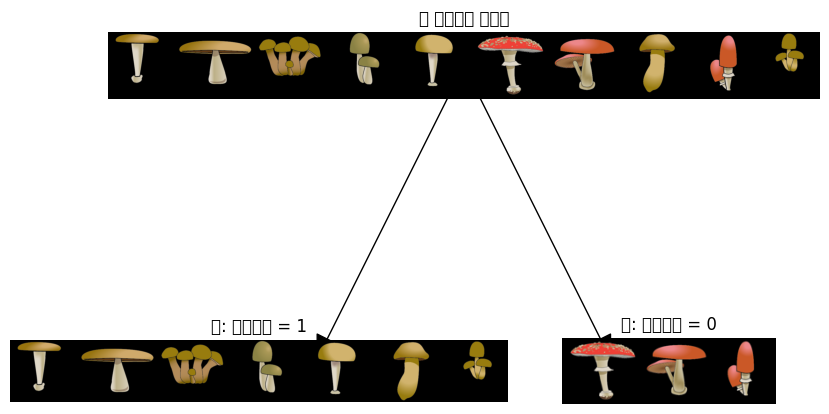


CASE 2:
Left indices:  [0, 2, 4]
Right indices:  [6, 8]


/home/dev/gpu/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 22312 (\N{CJK UNIFIED IDEOGRAPH-5728}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/dev/gpu/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 26837 (\N{CJK UNIFIED IDEOGRAPH-68D5}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/dev/gpu/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 33394 (\N{CJK UNIFIED IDEOGRAPH-8272}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/dev/gpu/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 33740 (\N{CJK UNIFIED IDEOGRAPH-83CC}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/dev/gpu/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 30422 (\N{CJK UNIFIED IDEOGRAPH-76D6}) m

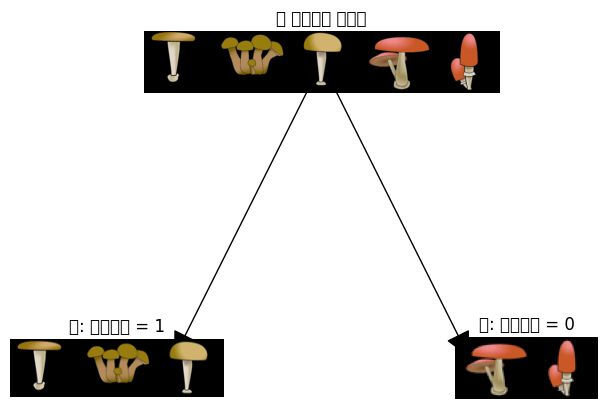

 All tests passed.


In [9]:
# Case 1

root_indices = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]

# 可以随意修改这些变量
# 数据集只有三个特征，所以该值可以是 0（棕色帽子）、1（锥形茎形状）或 2（独生）
feature = 0

left_indices, right_indices = split_dataset(X_train, root_indices, feature)

print("CASE 1:")
print("Left indices: ", left_indices)
print("Right indices: ", right_indices)

# 可视化分割 
generate_split_viz(root_indices, left_indices, right_indices, feature)

print()

# Case 2

root_indices_subset = [0, 2, 4, 6, 8]
left_indices, right_indices = split_dataset(X_train, root_indices_subset, feature)

print("CASE 2:")
print("Left indices: ", left_indices)
print("Right indices: ", right_indices)

# 可视化分割 
generate_split_viz(root_indices_subset, left_indices, right_indices, feature)

# 单元测试    
split_dataset_test(split_dataset)

**预期输出**：
```
CASE 1:
Left indices:  [0, 1, 2, 3, 4, 7, 9]
Right indices:  [5, 6, 8]

CASE 2:
Left indices:  [0, 2, 4]
Right indices:  [6, 8]
```

<a name="4.3"></a>
### 4.3  计算信息增益

接下来，你将编写一个名为`information_gain`的函数，该函数接收训练数据、节点的索引和要分割的特征，并返回分割的信息增益。

<a name="ex03"></a>
### 练习 3

请完成下面所示的`compute_information_gain()`函数以计算

$$\text{Information Gain} = H(p_1^\text{node})- (w^{\text{left}}H(p_1^\text{left}) + w^{\text{right}}H(p_1^\text{right}))$$

其中
- $H(p_1^\text{node})$ 是节点的熵
- $H(p_1^\text{left})$ 和 $H(p_1^\text{right})$ 是分割后左右分支的熵
- $w^{\text{left}}$ 和 $w^{\text{right}}$ 分别是左右分支的样本比例

注意：
- 你可以使用上面实现的`compute_entropy()`函数来计算熵
- 我们提供了一些起始代码，使用上面实现的`split_dataset()`函数来分割数据集

如果遇到困难，可以查看下面单元格后呈现的提示来帮助实现。

In [10]:
# UNQ_C3
# 评分函数：compute_information_gain

def compute_information_gain(X, y, node_indices, feature):
    
    """
    计算在给定特征上分割节点的信息增益
    
    参数：
        X (ndarray):            形状为(n_samples, n_features)的数据矩阵
        y (array like):         包含n_samples的目标变量的列表或ndarray
        node_indices (ndarray): 包含活动索引的列表，即此步骤中考虑的样本
   
    返回：
        cost (float):        计算的成本
    
    """    
    # 分割数据集
    left_indices, right_indices = split_dataset(X, node_indices, feature)
    
    # 一些有用的变量
    X_node, y_node = X[node_indices], y[node_indices]
    X_left, y_left = X[left_indices], y[left_indices]
    X_right, y_right = X[right_indices], y[right_indices]
    
    # 你需要正确返回以下变量
    information_gain = 0
    
    ### 开始编码 ###
    node_entropy = compute_entropy(y_node)
    
    left_entropy = compute_entropy(y_left)
    w_left = len(X_left) / len(X_node)
    
    right_entropy = compute_entropy(y_right)
    w_right = len(X_right) / len(X_node)
    
    information_gain = node_entropy - (w_left * left_entropy + w_right * right_entropy)
    ### 结束编码 ###  
    
    return information_gain

<details>
  <summary><font size="3" color="darkgreen"><b>点击获取提示</b></font></summary>
    
    
   * 以下是该函数的整体实现结构
    ```python 
    def compute_information_gain(X, y, node_indices, feature):
        # Split dataset
        left_indices, right_indices = split_dataset(X, node_indices, feature)

        # Some useful variables
        X_node, y_node = X[node_indices], y[node_indices]
        X_left, y_left = X[left_indices], y[left_indices]
        X_right, y_right = X[right_indices], y[right_indices]

        # You need to return the following variables correctly
        information_gain = 0

        ### START CODE HERE ###
        # Your code here to compute the entropy at the node using compute_entropy()
        node_entropy = 
        # Your code here to compute the entropy at the left branch
        left_entropy = 
        # Your code here to compute the entropy at the right branch
        right_entropy = 

        # Your code here to compute the proportion of examples at the left branch
        w_left = 
        
        # Your code here to compute the proportion of examples at the right branch
        w_right = 

        # Your code here to compute weighted entropy from the split using 
        # w_left, w_right, left_entropy and right_entropy
        weighted_entropy = 

        # Your code here to compute the information gain as the entropy at the node
        # minus the weighted entropy
        information_gain = 
        ### END CODE HERE ###  

        return information_gain
    ```
    如果仍然卡住，请查看下面的提示。
    
    <details>
          <summary><font size="2" color="darkblue"><b> 计算熵的提示</b></font></summary>
        
    <code>node_entropy = compute_entropy(y_node)</code><br>
    <code>left_entropy = compute_entropy(y_left)</code><br>
    <code>right_entropy = compute_entropy(y_right)</code>
        
    </details>
    
    <details>
          <summary><font size="2" color="darkblue"><b>计算 w_left 和 w_right 的提示</b></font></summary>
           <code>w_left = len(X_left) / len(X_node)</code><br>
           <code>w_right = len(X_right) / len(X_node)</code>
    </details>
    
    <details>
          <summary><font size="2" color="darkblue"><b>计算 weighted_entropy 的提示</b></font></summary>
           <code>weighted_entropy = w_left * left_entropy + w_right * right_entropy</code>
    </details>
    
    <details>
          <summary><font size="2" color="darkblue"><b>计算 information_gain 的提示</b></font></summary>
           <code> information_gain = node_entropy - weighted_entropy</code>
    </details>


</details>


你现在可以使用下面的单元格检查你的实现，并计算在每个特征上分割的信息增益

In [11]:
info_gain0 = compute_information_gain(X_train, y_train, root_indices, feature=0)
print("Information Gain from splitting the root on brown cap: ", info_gain0)

info_gain1 = compute_information_gain(X_train, y_train, root_indices, feature=1)
print("Information Gain from splitting the root on tapering stalk shape: ", info_gain1)

info_gain2 = compute_information_gain(X_train, y_train, root_indices, feature=2)
print("Information Gain from splitting the root on solitary: ", info_gain2)

# 单元测试
compute_information_gain_test(compute_information_gain)

Information Gain from splitting the root on brown cap:  0.034851554559677034
Information Gain from splitting the root on tapering stalk shape:  0.12451124978365313
Information Gain from splitting the root on solitary:  0.2780719051126377
 所有测试通过。


**预期输出**：
```
Information Gain from splitting the root on brown cap:  0.034851554559677034
Information Gain from splitting the root on tapering stalk shape:  0.12451124978365313
Information Gain from splitting the root on solitary:  0.2780719051126377
```

在根节点上对"独生"（特征 = 2）进行分割可获得最大信息增益。因此，它是在根节点上分割的最佳特征。

<a name="4.4"></a>
### 4.4  获取最佳分割
现在让我们编写一个函数，通过计算每个特征的信息增益（如上所述）并返回产生最大信息增益的特征来获取最佳分割特征

<a name="ex04"></a>
### 练习 4
请完成下面所示的`get_best_split()`函数。
- 该函数接收训练数据以及该节点数据点的索引
- 函数的输出是产生最大信息增益的特征
    - 你可以使用`compute_information_gain()`函数遍历特征并计算每个特征的信息增益
如果遇到困难，可以查看下面单元格后呈现的提示来帮助实现。

In [12]:
# UNQ_C4
# 评分函数：get_best_split

def get_best_split(X, y, node_indices):   
    """
    返回分割节点数据的最佳特征和阈值
    
    参数：
        X (ndarray):            形状为(n_samples, n_features)的数据矩阵
        y (array like):         包含n_samples的目标变量的列表或ndarray
        node_indices (ndarray): 包含活动索引的列表，即此步骤中考虑的样本

    返回：
        best_feature (int):     最佳分割特征的索引
    """    
    
    # 一些有用的变量
    num_features = X.shape[1]
    
    # 你需要正确返回以下变量
    best_feature = -1
    
    ### 开始编码 ###
    max_information_gain = 0.
    
    for feature in range(num_features):
        information_gain = compute_information_gain(X, y, node_indices, feature)
        if max_information_gain < information_gain:
            max_information_gain = information_gain
            best_feature = feature
            
    ### 结束编码 ##    
   
    return best_feature

<details>
  <summary><font size="3" color="darkgreen"><b>点击获取提示</b></font></summary>
    
    
   * 以下是该函数的整体实现结构
    
    ```python 
    def get_best_split(X, y, node_indices):   

        # Some useful variables
        num_features = X.shape[1]

        # You need to return the following variables correctly
        best_feature = -1

        ### START CODE HERE ###
        max_info_gain = 0

        # Iterate through all features
        for feature in range(num_features): 
            
            # Your code here to compute the information gain from splitting on this feature
            info_gain = 
            
            # If the information gain is larger than the max seen so far
            if info_gain > max_info_gain:  
                # Your code here to set the max_info_gain and best_feature
                max_info_gain = 
                best_feature = 
        ### END CODE HERE ##    
   
    return best_feature
    ```
    如果仍然卡住，请查看下面的提示。
    
    <details>
          <summary><font size="2" color="darkblue"><b> 计算 info_gain 的提示</b></font></summary>
        
    <code>info_gain = compute_information_gain(X, y, node_indices, feature)</code>
    </details>
    
    <details>
          <summary><font size="2" color="darkblue"><b>更新 max_info_gain 和 best_feature 的提示</b></font></summary>
           <code>max_info_gain = info_gain</code><br>
           <code>best_feature = feature</code>
    </details>
</details>


现在，让我们使用下面的单元格检查你的函数实现。

In [13]:
best_feature = get_best_split(X_train, y_train, root_indices)
print("Best feature to split on: %d" % best_feature)

# 单元测试
get_best_split_test(get_best_split)

Best feature to split on: 2
 所有测试通过。


如我们上面所见，函数返回在根节点上分割的最佳特征是特征2（"独生"）

<a name="5"></a>
## 5 - 构建决策树

在本节中，我们使用你上面实现的函数，通过连续选择最佳分割特征直到达到停止条件（最大深度为2）来生成决策树。

此部分无需实现任何内容。

In [14]:
# 非评分
tree = []

def build_tree_recursive(X, y, node_indices, branch_name, max_depth, current_depth):
    """
    使用递归算法构建树，在每个节点将数据集分割为两个子组。
    此函数仅打印树。
    
    参数：
        X (ndarray):            形状为(n_samples, n_features)的数据矩阵
        y (array like):         包含n_samples的目标变量的列表或ndarray
        node_indices (ndarray): 包含活动索引的列表，即此步骤中考虑的样本
        branch_name (string):   分支的名称。['Root', 'Left', 'Right']
        max_depth (int):        结果树的最大深度
        current_depth (int):    当前深度。递归调用时使用的参数
   
    """ 

    # 达到最大深度 - 停止分割
    if current_depth == max_depth:
        formatting = " "*current_depth + "-"*current_depth
        print(formatting, "%s leaf node with indices" % branch_name, node_indices)
        return
   
    # 否则，获取最佳分割并分割数据
    # 获取该节点的最佳特征和阈值
    best_feature = get_best_split(X, y, node_indices) 
    
    formatting = "-"*current_depth
    print("%s Depth %d, %s: Split on feature: %d" % (formatting, current_depth, branch_name, best_feature))
    
    # 在最佳特征处分割数据集
    left_indices, right_indices = split_dataset(X, node_indices, best_feature)
    tree.append((left_indices, right_indices, best_feature))
    
    # 继续分割左右子节点。增加当前深度
    build_tree_recursive(X, y, left_indices, "Left", max_depth, current_depth+1)
    build_tree_recursive(X, y, right_indices, "Right", max_depth, current_depth+1)

 Depth 0, Root: Split on feature: 2
- Depth 1, Left: Split on feature: 0
  -- Left leaf node with indices [0, 1, 4, 7]
  -- Right leaf node with indices [5]
- Depth 1, Right: Split on feature: 1
  -- Left leaf node with indices [8]
  -- Right leaf node with indices [2, 3, 6, 9]


/home/dev/gpu/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 22312 (\N{CJK UNIFIED IDEOGRAPH-5728}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/dev/gpu/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 19978 (\N{CJK UNIFIED IDEOGRAPH-4E0A}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/dev/gpu/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 20998 (\N{CJK UNIFIED IDEOGRAPH-5206}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/dev/gpu/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 21106 (\N{CJK UNIFIED IDEOGRAPH-5272}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/dev/gpu/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 29420 (\N{CJK UNIFIED IDEOGRAPH-72EC}) m

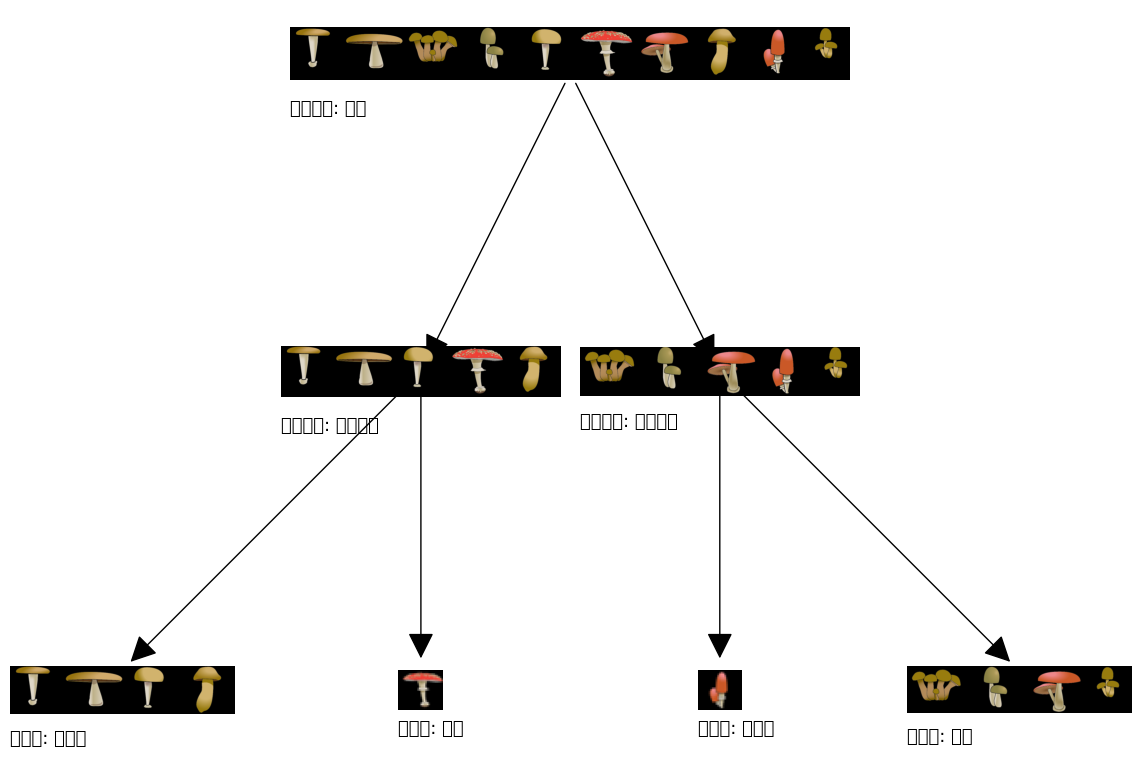

In [15]:
build_tree_recursive(X_train, y_train, root_indices, "Root", max_depth=2, current_depth=0)
generate_tree_viz(root_indices, y_train, tree)

<details>
  <summary><font size="2" color="darkgreen"><b>如果你想尝试任何非评分代码，请点击此处。</b></font></summary>
    <p><i><b>重要提示：请仅在通过作业后执行此操作，以避免自动评分器出现问题。</b></i>
    <ol>
        <li> 在notebook菜单中，点击"查看" > "单元格工具栏" > "编辑元数据"</li>
        <li> 点击要锁定/解锁的代码单元格旁边的"编辑元数据"按钮</li>
        <li> 将"editable"属性值设置为：
            <ul>
                <li> 如果要解锁，设置为"true"</li>
                <li> 如果要锁定，设置为"false"</li>
            </ul>
        </li>
        <li> 在notebook菜单中，点击"查看" > "单元格工具栏" > "无"</li>
    </ol>
    <p> 以下是上述步骤的简短视频演示：
        <br>
        <img src="https://drive.google.com/uc?export=view&id=14Xy_Mb17CZVgzVAgq7NCjMVBvSae3xO1" align="center" alt="unlock_cells.gif">
</details>